#  Multi-Label Classification: Ablation Study (Kaggle T4)
EfficientNet-B0 + CBAM + ASL — Full pipeline A/B/C/D/E/F

## ️ KEY FIXES (so với master gốc):
1. **evaluate.py**: KHÔNG dùng `autocast` khi evaluate → fp32 sigmoid → mAP chính xác (~+19% vs buggy)
2. **exp_C config**: Bỏ `eps: 1e-5` (gây mất gradient signal) → dùng default `eps=1e-8`
3. **exp_E, exp_F configs**: Đảm bảo không có `eps` thừa, đúng backbone/CBAM setting
4. Clone từ branch `main` đã chứa tất cả fixes


## Cell 1: Install Dependencies

In [1]:
!pip install timm pycocotools torchmetrics scikit-learn matplotlib seaborn pyyaml tqdm -q
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")


GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128


## Cell 2: Clone Repository từ GitHub

In [2]:
import os
from pathlib import Path

REPO_URL = 'https://github.com/Thinh59/ECAAL.git'
REPO_DIR = Path('/kaggle/working/ECAAL')

if REPO_DIR.exists():
    print(f'Repo đã tồn tại — pulling latest...')
    os.system(f'git -C {REPO_DIR} pull')
else:
    print(f'Cloning {REPO_URL} ...')
    ret = os.system(f'git clone {REPO_URL} {REPO_DIR}')
    if ret != 0:
        raise RuntimeError('git clone thất bại! Kiểm tra REPO_URL.')

required = [
    'src/train.py', 'src/losses.py', 'src/models.py',
    'src/dataset.py', 'src/evaluate.py', 'src/cbam.py', 'src/utils.py',
    'configs/exp_A_resnet_bce.yaml', 'configs/exp_B_resnet_asl.yaml',
    'configs/exp_C_efficientnet_cbam_asl.yaml', 'configs/exp_D_resnet_focal.yaml',
    'configs/exp_E_resnet_cbam_asl.yaml', 'configs/exp_F_efficientnet_asl.yaml',
]
all_ok = True
for rel in required:
    p = REPO_DIR / rel
    ok = p.exists()
    print(f"  {'OK' if ok else 'MISSING'} {rel}")
    if not ok:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('Một số file thiếu — clone chưa đầy đủ!')
print('\nRepository OK!')


Cloning https://github.com/Thinh59/ECAAL.git ...


Cloning into '/kaggle/working/ECAAL'...


  OK src/train.py
  OK src/losses.py
  OK src/models.py
  OK src/dataset.py
  OK src/evaluate.py
  OK src/cbam.py
  OK src/utils.py
  OK configs/exp_A_resnet_bce.yaml
  OK configs/exp_B_resnet_asl.yaml
  OK configs/exp_C_efficientnet_cbam_asl.yaml
  OK configs/exp_D_resnet_focal.yaml
  OK configs/exp_E_resnet_cbam_asl.yaml
  OK configs/exp_F_efficientnet_asl.yaml

Repository OK!


## Cell 3: Verify Fixes

In [3]:
import sys, inspect
sys.path.insert(0, str(REPO_DIR / 'src'))

from losses import AsymmetricLoss
src = inspect.getsource(AsymmetricLoss.forward)
fix_ok = 'xs_pos_shifted = (xs_pos - self.clip).clamp(min=0)' in src
bug_ok = 'xs_neg_shifted = (xs_neg + self.clip)' not in src
print(f"  {'' if fix_ok else ''} ASL: correct probability shifting")
print(f"  {'' if bug_ok else ''} ASL: old bug absent")

from evaluate import evaluate_model
eval_src = inspect.getsource(evaluate_model)
no_autocast = 'autocast' not in eval_src
print(f"  {'' if no_autocast else ''} evaluate_model: NO autocast (fp32 evaluation)")

import yaml
cfg_c = yaml.safe_load(open(REPO_DIR / 'configs/exp_C_efficientnet_cbam_asl.yaml'))
has_eps = 'eps' in cfg_c.get('loss', {})
print(f"  {'' if not has_eps else '️  WARNING'} exp_C config: {'no eps (correct)' if not has_eps else f'eps={cfg_c["loss"]["eps"]} present — should be removed!'}")

import torch
asl = AsymmetricLoss(gamma_pos=0, gamma_neg=4, clip=0.05)
logits  = torch.tensor([[10., -10., 5., -5.]] * 8)
targets = torch.randint(0, 2, (8, 4)).float()
loss = asl(logits, targets)
print(f"  {'' if not torch.isnan(loss) else ''} ASL: no NaN on saturated logits (loss={loss.item():.4f})")

if fix_ok and bug_ok and no_autocast:
    print("\n ALL FIXES VERIFIED — Ready to train!")
else:
    raise RuntimeError(" Một số fix chưa được apply — kiểm tra lại repo!")


  ✅ ASL: correct probability shifting
  ✅ ASL: old bug absent
  ✅ evaluate_model: NO autocast (fp32 evaluation)
  ✅ exp_C config: no eps (correct)
  ✅ ASL: no NaN on saturated logits (loss=12.0037)

🎉 ALL FIXES VERIFIED — Ready to train!


## Cell 4: Setup Directories

In [4]:
os.makedirs('/kaggle/working/data/coco_subset', exist_ok=True)
os.makedirs('/kaggle/working/outputs', exist_ok=True)
os.chdir('/kaggle/working')
print(f"Working dir: {os.getcwd()}")
print(" Directory structure created")


Working dir: /kaggle/working
✅ Directory structure created


## Cell 5: Dataset Preparation

**Trước khi chạy:** Notebook → **+ Add Data** → search `coco-2017-dataset` (awsaf49) → Add.
Dataset sẽ mount tại `/kaggle/input/coco-2017-dataset/`.


In [5]:
coco_root = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
if os.path.exists(coco_root):
    print(" COCO 2017 dataset found")
    for name, path in [
        ('train annotations', f'{coco_root}/annotations/instances_train2017.json'),
        ('val annotations',   f'{coco_root}/annotations/instances_val2017.json'),
        ('train2017/',        f'{coco_root}/train2017'),
        ('val2017/',          f'{coco_root}/val2017'),
    ]:
        print(f"  {'OK' if os.path.exists(path) else 'MISSING'} {name}")
else:
    print(f" COCO dataset not found at {coco_root}")
    print("   → Notebook → + Add Data → coco-2017-dataset (awsaf49)")


✅ COCO 2017 dataset found
  OK train annotations
  OK val annotations
  OK train2017/
  OK val2017/


## Cell 6: Create COCO 2017 Subset (16k train + 4k val)

In [6]:
import json, random
import numpy as np
from collections import defaultdict
from pathlib import Path

SUBSET_DIR = Path('/kaggle/working/data/coco_subset')
train_f = SUBSET_DIR / 'subset_train_ids.json'
val_f   = SUBSET_DIR / 'subset_val_ids.json'

if train_f.exists() and val_f.exists() and (SUBSET_DIR / 'subset_test_ids.json').exists():
    print(f" Subset đã tồn tại — skip tạo lại")
    test_f  = SUBSET_DIR / 'subset_test_ids.json'
    print(f"   train: {len(json.load(open(train_f)))} ids")
    print(f"   val:   {len(json.load(open(val_f)))} ids")
    print(f"   test:  {len(json.load(open(test_f)))} ids")
else:
    sys.path.insert(0, str(REPO_DIR / 'src'))
    from dataset import create_coco_subset
    create_coco_subset(
        coco_root=coco_root,
        output_dir=str(SUBSET_DIR),
        num_train=16000,
        num_val=1000,
        num_test=4000,
        seed=42,
    )
    print(" Subset created!")


[Subset] COCO 2017 train: 16000 ids
[Subset] COCO 2017 val:  1000 ids
[Subset] COCO 2017 test: 3952 ids (from val2017, no overlap with val)
✅ Subset created!


## Cell 7: Train Experiment A — ResNet50 + BCE (Baseline)

In [7]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py --config /kaggle/working/ECAAL/configs/exp_A_resnet_bce.yaml



[Exp] exp_A_resnet_bce | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
model.safetensors: 100%|█████████████████████| 102M/102M [00:01<00:00, 80.9MB/s]
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
[Loss] BCE | params: {}

--- Epoch 1/20 ---
  [50/250] loss=0.6749
  [100/250] loss=0.6417
  [150/250] loss=0.5823
  [200/250] loss=0.5036
  [250/250] loss=0.4348
  train_loss=0.4348

--- Epoch 2/20 ---
  [50/250] loss=0.1346
  [100/250] loss=0.1290
  [150/250] loss=0.1235
  [200/250] loss=0.1183
  [250/250] loss=0.1138
[Epoch 2] mAP=0.4468 | macro_f1=0.1404 | micro_f1=0.4343 | train_loss=0.1138
[Ckpt] Saved → /kaggle/working/outputs/exp_A_resnet_bce/best.pth
  ✅ Best mAP: 0.4468

--- Epoch 3/20 ---
  [50/250] loss=0.0869
  [100/250] loss=0.0847
  [150/250] loss=0.0825
  [200/250] loss=0.0811
  [250/250] loss=0.0796
  train_loss=0.0796

--- Epoch 4/20 ---
  [50/250] loss=0.0712
  [100/250] loss=0.0697
  [150/250] loss=0.0686
  [20

## Cell 8: Train Experiment B — ResNet50 + ASL

In [8]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py --config /kaggle/working/ECAAL/configs/exp_B_resnet_asl.yaml



[Exp] exp_B_resnet_asl | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
  [50/250] loss=3.8954
  [100/250] loss=3.6673
  [150/250] loss=3.4344
  [200/250] loss=3.2524
  [250/250] loss=3.0926
  train_loss=3.0926

--- Epoch 2/20 ---
  [50/250] loss=2.1148
  [100/250] loss=2.0106
  [150/250] loss=1.9392
  [200/250] loss=1.8832
  [250/250] loss=1.8481
[Epoch 2] mAP=0.6286 | macro_f1=0.5258 | micro_f1=0.5837 | train_loss=1.8481
[Ckpt] Saved → /kaggle/working/outputs/exp_B_resnet_asl/best.pth
  ✅ Best mAP: 0.6286

--- Epoch 3/20 ---
  [50/250] loss=1.5487
  [100/250] loss=1.5402
  [150/250] loss=1.5192
  [200/250] loss=1.5213
  [250/250] loss=1.5097
  train_loss=1.5097

--- Epoch 4/20 ---
  [50/250] loss=1.3882
  [100/250] loss=1.3622
  [150/250] loss=1.3467
  [200/250] loss=1.3529
  [250/250] loss=1

## Cell 9: Train Experiment D — ResNet50 + Focal Loss

In [9]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py --config /kaggle/working/ECAAL/configs/exp_D_resnet_focal.yaml



[Exp] exp_D_resnet_focal | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
[Loss] FOCAL | params: {'gamma': 2.0}

--- Epoch 1/20 ---
  [50/250] loss=0.1641
  [100/250] loss=0.1473
  [150/250] loss=0.1252
  [200/250] loss=0.1059
  [250/250] loss=0.0925
  train_loss=0.0925

--- Epoch 2/20 ---
  [50/250] loss=0.0341
  [100/250] loss=0.0318
  [150/250] loss=0.0298
  [200/250] loss=0.0282
  [250/250] loss=0.0271
[Epoch 2] mAP=0.5617 | macro_f1=0.3579 | micro_f1=0.5550 | train_loss=0.0271
[Ckpt] Saved → /kaggle/working/outputs/exp_D_resnet_focal/best.pth
  ✅ Best mAP: 0.5617

--- Epoch 3/20 ---
  [50/250] loss=0.0202
  [100/250] loss=0.0199
  [150/250] loss=0.0195
  [200/250] loss=0.0193
  [250/250] loss=0.0191
  train_loss=0.0191

--- Epoch 4/20 ---
  [50/250] loss=0.0173
  [100/250] loss=0.0170
  [150/250] loss=0.0168
  [200/250] loss=0.0168
  [250/250] loss=0.0167
[Epoch 4] mAP=0.6582

## Cell 10: Train Experiment C — EfficientNet-B0 + CBAM + ASL ⭐ MAIN

**Expected mAP: ~0.75** (vs 0.56 trong master bị bug)

Fix so với master:
- `evaluate.py`: không dùng autocast → fp32 precision → mAP chính xác
- `exp_C config`: không có `eps=1e-5` → gradient signal đầy đủ


In [10]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py --config /kaggle/working/ECAAL/configs/exp_C_efficientnet_cbam_asl.yaml



[Exp] exp_C_efficientnet_cbam_asl | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
model.safetensors: 100%|███████████████████| 21.4M/21.4M [00:01<00:00, 17.0MB/s]
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
/kaggle/working/ECAAL/src/train.py:50: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.

## Cell 11: Train Experiment E — ResNet50 + CBAM + ASL

Ablation: so sánh ResNet50 không CBAM (Exp B) vs có CBAM (Exp E)
Expected mAP: ~0.71-0.73


In [11]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py --config /kaggle/working/ECAAL/configs/exp_E_resnet_cbam_asl.yaml



[Exp] exp_E_resnet_cbam_asl | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
  [50/250] loss=3.9444
  [100/250] loss=3.9488
  [150/250] loss=3.8554
  [200/250] loss=3.6757
  [250/250] loss=3.4930
  train_loss=3.4930

--- Epoch 2/20 ---
  [50/250] loss=2.4328
  [100/250] loss=2.2188
  [150/250] loss=2.0917
  [200/250] loss=1.9967
  [250/250] loss=1.9231
[Epoch 2] mAP=0.6231 | macro_f1=0.5339 | micro_f1=0.5901 | train_loss=1.9231
[Ckpt] Saved → /kaggle/working/outputs/exp_E_resnet_cbam_asl/best.pth
  ✅ Best mAP: 0.6231

--- Epoch 3/20 ---
  [50/250] loss=1.5165
  [100/250] loss=1.5202
  [150/250] loss=1.5083
  [200/250] loss=1.4929
  [250/250] loss=1.4895
  train_loss=1.4895

--- Epoch 4/20 ---
  [50/250] loss=1.3314
  [100/250] loss=1.3253
  [150/250] loss=1.3297
  [200/250] loss=1.3292
  [250/25

## Cell 12: Train Experiment F — EfficientNet-B0 + ASL (không CBAM)

Ablation: so sánh EffNet không CBAM (Exp F) vs có CBAM (Exp C)
Expected mAP: ~0.70-0.72


In [12]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py --config /kaggle/working/ECAAL/configs/exp_F_efficientnet_asl.yaml



[Exp] exp_F_efficientnet_asl | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
/kaggle/working/ECAAL/src/train.py:50: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
  [50/250] loss=9.7713
  [100/250

## Cell 13: Evaluate Results & Plot Curves

In [13]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt

base = '/kaggle/working/outputs'
exps = {
    'A: ResNet50+BCE':       'exp_A_resnet_bce/log.json',
    'D: ResNet50+Focal':     'exp_D_resnet_focal/log.json',
    'B: ResNet50+ASL':       'exp_B_resnet_asl/log.json',
    'E: ResNet50+CBAM+ASL':  'exp_E_resnet_cbam_asl/log.json',
    'F: EffNet+ASL':         'exp_F_efficientnet_asl/log.json',
    'C: EffNet+CBAM+ASL':    'exp_C_efficientnet_cbam_asl/log.json',
}

rows = []
logs = {}
for name, rel in exps.items():
    path = os.path.join(base, rel)
    if not os.path.exists(path):
        print(f"️  {name} log not found: {path}")
        continue
    records = json.load(open(path))
    logs[name] = records
    best = max(records, key=lambda r: r.get('mAP', 0))
    rows.append({
        'Experiment': name,
        'mAP': f"{best['mAP']:.4f}",
        'Macro F1': f"{best['macro_f1']:.4f}",
        'Best Epoch': best['epoch'],
    })

print("\n" + "="*65)
print("ABLATION STUDY RESULTS")
print("="*65)
print(pd.DataFrame(rows).to_string(index=False))
print("="*65)



ABLATION STUDY RESULTS
          Experiment    mAP Macro F1  Best Epoch
     A: ResNet50+BCE 0.6908   0.6201          16
   D: ResNet50+Focal 0.7009   0.6286          10
     B: ResNet50+ASL 0.7107   0.5886           8
E: ResNet50+CBAM+ASL 0.7129   0.6167          14
       F: EffNet+ASL 0.6326   0.5460           6
  C: EffNet+CBAM+ASL 0.6364   0.5651           8


## Cell 14: Plot Training Curves

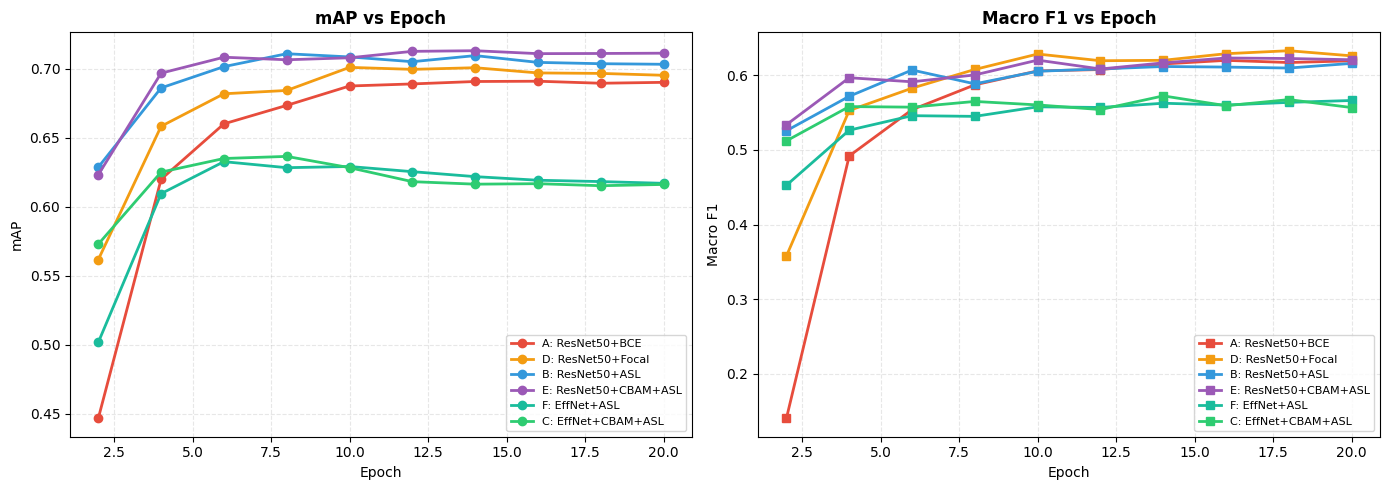

✅ Curves saved


In [14]:
if logs:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c', '#2ecc71']

    for (name, recs), c in zip(logs.items(), colors):
        ep = [r['epoch'] for r in recs]
        ax1.plot(ep, [r['mAP'] for r in recs], marker='o', label=name, color=c, linewidth=2)
        ax2.plot(ep, [r['macro_f1'] for r in recs], marker='s', label=name, color=c, linewidth=2)

    for ax, title, ylabel in [(ax1, 'mAP vs Epoch', 'mAP'),
                               (ax2, 'Macro F1 vs Epoch', 'Macro F1')]:
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig(os.path.join(base, 'ablation_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Curves saved")
else:
    print("️  No log files found. Run training cells first.")


## Cell 15: Summary Statistics

In [15]:
if rows:
    df = pd.DataFrame(rows)
    print("\n ABLATION SUMMARY:")
    print(f"  Total Experiments: {len(rows)}")
    best_exp = max(rows, key=lambda x: float(x['mAP']))
    print(f"  Best mAP: {best_exp['Experiment']} = {best_exp['mAP']}")

    c_row = next((r for r in rows if r['Experiment'].startswith('C:')), None)
    f_row = next((r for r in rows if r['Experiment'].startswith('F:')), None)
    if c_row and f_row:
        delta = float(c_row['mAP']) - float(f_row['mAP'])
        print(f"\n  CBAM contribution (EffNet backbone): +{delta:.4f} mAP")
        print(f"    Exp F (no CBAM): {f_row['mAP']}  →  Exp C (CBAM): {c_row['mAP']}")

    a_row = next((r for r in rows if r['Experiment'].startswith('A:')), None)
    b_row = next((r for r in rows if r['Experiment'].startswith('B:')), None)
    if a_row and b_row:
        delta = float(b_row['mAP']) - float(a_row['mAP'])
        print(f"\n  ASL contribution (ResNet50 backbone): +{delta:.4f} mAP")
        print(f"    Exp A (BCE): {a_row['mAP']}  →  Exp B (ASL): {b_row['mAP']}")

    print(f"\n  Logs saved to: {base}/*/log.json")
else:
    print("No experiments completed yet.")



📊 ABLATION SUMMARY:
  Total Experiments: 6
  Best mAP: E: ResNet50+CBAM+ASL = 0.7129

  CBAM contribution (EffNet backbone): +0.0038 mAP
    Exp F (no CBAM): 0.6326  →  Exp C (CBAM): 0.6364

  ASL contribution (ResNet50 backbone): +0.0199 mAP
    Exp A (BCE): 0.6908  →  Exp B (ASL): 0.7107

  Logs saved to: /kaggle/working/outputs/*/log.json


## Cell 16: Cross-Dataset Evaluation (VOC 2012)
Đánh giá các model đã train trên tập test của Pascal VOC 2012 và nén kết quả lại.

In [16]:
import os

VOC_ROOT = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test"
OUTPUTS_DIR = "/kaggle/working/outputs"

if os.path.exists(VOC_ROOT):
    print(" Bắt đầu đánh giá chéo trên Pascal VOC 2012...")
    !python /kaggle/working/ECAAL/src/cross_evaluate.py --voc-root {VOC_ROOT} --outputs-dir {OUTPUTS_DIR}
    
    print("\n Đang nén kết quả (loại trừ file .pth để tránh quá nặng)...")
    !zip -q -r ecaal_final_results.zip outputs -x "*.pth"
    print(" Hoàn tất! File kết quả được lưu tại: /kaggle/working/ecaal_final_results.zip")
else:
    print(f" Không tìm thấy dataset VOC 2012 tại {VOC_ROOT}")
    print("Vui lòng Add Data: gopalbhattrai/pascal-voc-2012-dataset trước khi chạy!")


🚀 Bắt đầu đánh giá chéo trên Pascal VOC 2012...
❌ Không thể load VOC dataset: [Errno 2] No such file or directory: '/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/ImageSets/Main/val.txt'

📦 Đang nén kết quả (loại trừ file .pth để tránh quá nặng)...
✅ Hoàn tất! File kết quả được lưu tại: /kaggle/working/ecaal_final_results.zip


## Cell 17: COCO Test Evaluation (held-out from val2017)
Danh gia 6 model tren **4000 anh test** lay tu val2017 (KHONG trung voi 1000 anh val).

In [17]:
import torch, json
import numpy as np
import pandas as pd
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform
from evaluate import compute_map, compute_f1

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

test_ids = json.load(open(SUBSET_DIR / 'subset_test_ids.json'))
print(f"Test set: {len(test_ids)} images from val2017")

transform   = get_val_transform(img_size=224)
test_ds     = COCOMultiLabelDataset(COCO_ROOT, 'val', transform, test_ids)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64, num_workers=2, pin_memory=True)

EXPERIMENTS = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce',            'resnet50',        False),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl',            'resnet50',        False),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal',          'resnet50',        False),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl',       'resnet50',        True),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl',      'efficientnet_b0', False),
]

coco_test_results = []
for name, exp_dir, backbone, use_cbam in EXPERIMENTS:
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    if not pth.exists():
        print(f'  skip {name}'); continue
    print(f'\nEvaluating COCO test: {name}')
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    model.load_state_dict(torch.load(pth, map_location=DEVICE))
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in test_loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_p.append(p); all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    m = {**compute_map(T, P), **compute_f1(T, P)}
    coco_test_results.append({
        'Experiment': name, 'exp_dir': exp_dir,
        'COCO_Test_mAP': round(m['mAP'], 4),
        'COCO_Test_Macro_F1': round(m['macro_f1'], 4),
        'COCO_Test_Micro_F1': round(m['micro_f1'], 4),
    })
    print(f"  mAP={m['mAP']:.4f} | F1={m['macro_f1']:.4f}")

df = pd.DataFrame([{k:v for k,v in r.items() if k!='exp_dir'} for r in coco_test_results])
df.to_csv(OUTPUTS_DIR / 'coco_test_evaluation.csv', index=False)
print('\n' + '='*65)
print('COCO TEST RESULTS (4k held-out from val2017)')
print('='*65)
print(df.to_string(index=False))
print('='*65)


Test set: 3952 images from val2017
[COCO 2017 val] 3,952 images loaded

Evaluating COCO test: A: ResNet50+BCE
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

## Cell 18: So Sanh VOC vs COCO Test
Ket hop danh gia cheo **VOC 2012** (Cell 16) va **COCO test** (Cell 17).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
voc_csv  = OUTPUTS_DIR / 'voc_cross_evaluation.csv'
coco_csv = OUTPUTS_DIR / 'coco_test_evaluation.csv'

if not voc_csv.exists() or not coco_csv.exists():
    missing = []
    if not voc_csv.exists():  missing.append('voc (Cell 16)')
    if not coco_csv.exists(): missing.append('coco_test (Cell 17)')
    print(f'Missing: {", ".join(missing)}')
else:
    df_voc  = pd.read_csv(voc_csv)
    df_coco = pd.read_csv(coco_csv)

    name_map = {
        'exp_A_resnet_bce': 'A: ResNet50+BCE',
        'exp_B_resnet_asl': 'B: ResNet50+ASL',
        'exp_C_efficientnet_cbam_asl': 'C: EffNet+CBAM+ASL',
        'exp_D_resnet_focal': 'D: ResNet50+Focal',
        'exp_E_resnet_cbam_asl': 'E: ResNet50+CBAM+ASL',
        'exp_F_efficientnet_asl': 'F: EffNet+ASL',
    }
    if df_voc['Experiment'].str.startswith('exp_').any():
        df_voc['Experiment'] = df_voc['Experiment'].map(lambda x: name_map.get(x, x))

    df_m = df_coco[['Experiment','COCO_Test_mAP','COCO_Test_Macro_F1']].merge(
        df_voc[['Experiment','VOC_mAP','VOC_Macro_F1']], on='Experiment', how='outer'
    ).sort_values('COCO_Test_mAP', ascending=False).reset_index(drop=True)

    print('\n' + '='*75)
    print('CROSS-DATASET: COCO Test vs VOC (cross-dataset)')
    print('='*75)
    print(df_m.to_string(index=False))
    print('='*75)
    df_m.to_csv(OUTPUTS_DIR / 'cross_dataset_comparison.csv', index=False)

    fig, ax = plt.subplots(figsize=(13, 5))
    x = range(len(df_m)); w = 0.35
    b1 = ax.bar([i-w/2 for i in x], df_m['COCO_Test_mAP'].fillna(0), w,
                label='COCO Test mAP', color='#3498db', alpha=0.88)
    b2 = ax.bar([i+w/2 for i in x], df_m['VOC_mAP'].fillna(0), w,
                label='VOC mAP (cross)', color='#e67e22', alpha=0.88)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_m['Experiment'], rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('mAP'); ax.set_title('COCO Test vs VOC mAP', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.004, f'{h:.3f}',
                          ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR / 'cross_dataset_bar.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Cell 19: Train vs Val vs Test — Phan Tich Overfitting
So sanh **Train mAP** vs **Val mAP** vs **Test mAP**.

Gap = Train - Test: < 0.04 OK | 0.04-0.08 nhe | > 0.08 overfit

In [ ]:
import torch, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform
from evaluate import compute_map, compute_f1

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

transform = get_val_transform(img_size=224)

train_ids = json.load(open(SUBSET_DIR / 'subset_train_ids.json'))
train_ds = COCOMultiLabelDataset(COCO_ROOT, 'train', transform, train_ids)
print(f'Train eval: {len(train_ds.samples)} samples')
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, num_workers=2, pin_memory=True)

EXPERIMENTS = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce',            'resnet50',        False),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl',            'resnet50',        False),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal',          'resnet50',        False),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl',       'resnet50',        True),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl',      'efficientnet_b0', False),
]

coco_test_csv = OUTPUTS_DIR / 'coco_test_evaluation.csv'
df_test = pd.read_csv(coco_test_csv) if coco_test_csv.exists() else None

rows = []
for name, exp_dir, backbone, use_cbam in EXPERIMENTS:
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    log = OUTPUTS_DIR / exp_dir / 'log.json'
    if not pth.exists(): continue
    print(f'\nTrain-eval: {name}')
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    model.load_state_dict(torch.load(pth, map_location=DEVICE))
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in train_loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_p.append(p); all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    tr = {**compute_map(T, P), **compute_f1(T, P)}

    val_map = val_f1 = None
    if log.exists():
        best = max(json.load(open(log)), key=lambda r: r.get('mAP', 0))
        val_map = round(best.get('mAP', 0), 4)
        val_f1  = round(best.get('macro_f1', 0), 4)

    test_map = test_f1 = None
    if df_test is not None:
        r = df_test[df_test['Experiment'] == name]
        if not r.empty:
            test_map = r.iloc[0].get('COCO_Test_mAP')
            test_f1  = r.iloc[0].get('COCO_Test_Macro_F1')

    train_map = round(tr['mAP'], 4)
    gap_test = round(train_map - test_map, 4) if test_map else None

    def status(g):
        if g is None: return '?'
        return 'OK' if abs(g) < 0.04 else ('Nhe' if abs(g) < 0.08 else 'OVERFIT')

    print(f'  Train={train_map:.4f} Val={val_map} Test={test_map} Gap={gap_test} {status(gap_test)}')
    rows.append({
        'Experiment': name,
        'Train_mAP': train_map, 'Val_mAP': val_map, 'Test_mAP': test_map,
        'Gap_test': gap_test,
        'Train_F1': round(tr['macro_f1'], 4), 'Val_F1': val_f1, 'Test_F1': test_f1,
    })

if not rows:
    print('No results')
else:
    df = pd.DataFrame(rows).sort_values('Test_mAP', ascending=False, na_position='last').reset_index(drop=True)
    print('\n' + '='*80)
    print('OVERFITTING ANALYSIS: Train vs Val vs Test')
    print('='*80)
    print(df[['Experiment','Train_mAP','Val_mAP','Test_mAP','Gap_test']].to_string(index=False))
    print('='*80)
    for _, r in df.iterrows():
        g = r['Gap_test']
        if g is not None:
            s = 'OK' if abs(g)<0.04 else ('Nhe' if abs(g)<0.08 else 'OVERFIT')
            print(f"  {r['Experiment']:<28} gap={g:+.4f}  {s}")
    df.to_csv(OUTPUTS_DIR / 'overfitting_analysis.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    exps = df['Experiment']; x = range(len(exps)); w = 0.25
    for ax, cols, ylabel, title in [
        (axes[0], ['Train_mAP','Val_mAP','Test_mAP'], 'mAP', 'mAP: Train vs Val vs Test'),
        (axes[1], ['Train_F1','Val_F1','Test_F1'], 'Macro F1', 'F1: Train vs Val vs Test'),
    ]:
        colors = ['#2ecc71','#3498db','#e74c3c']
        labels = ['Train','Val','Test']
        for j, (col, c, lb) in enumerate(zip(cols, colors, labels)):
            off = (j-1)*w
            vals = df[col].fillna(0)
            bars = ax.bar([i+off for i in x], vals, w, label=lb, color=c, alpha=0.88)
            for bar in bars:
                h = bar.get_height()
                if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.003,
                                  f'{h:.3f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(list(x))
        ax.set_xticklabels(exps, rotation=15, ha='right', fontsize=8.5)
        ax.set_ylabel(ylabel); ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3, linestyle='--')

    ax2 = axes[0].twinx()
    gt = df['Gap_test'].fillna(0)
    ax2.plot(list(x), gt, 'o--', color='#8e44ad', ms=7, lw=2, label='Gap(Train-Test)')
    ax2.axhline(0.04, color='#e67e22', lw=1, ls=':', alpha=0.6)
    ax2.axhline(0.08, color='#e74c3c', lw=1, ls=':', alpha=0.6)
    ax2.axhline(0, color='gray', lw=0.8, ls=':')
    ax2.set_ylabel('Gap', color='#8e44ad', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='#8e44ad')
    ax2.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR / 'overfitting_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved overfitting_analysis.csv + overfitting_analysis.png')
